In [1]:
#Figures and stats for VIIRS candidate fires for 2020 Western US fires
#Shane Coffield coffield@umd.edu July 2025
#runs on pangeo env on NASA MAAP ADE

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy
import pandas as pd
import geopandas as gpd
import os
import datetime as dt
import matplotlib as mpl
from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gs
import matplotlib.dates as mdates
import rasterio
import warnings
from scipy import stats
import rioxarray #for tree cover tif

In [3]:
def scale_bar(ax, length=None, location=(0.15, 0.05), linewidth=3):
    """
    ax is the axes to draw the scalebar on.
    length is the length of the scalebar in km.
    location is center of the scalebar in axis coordinates.
    (ie. 0.5 is the middle of the plot)
    linewidth is the thickness of the scalebar.
    credit: https://stackoverflow.com/questions/32333870/how-can-i-show-a-km-ruler-on-a-cartopy-matplotlib-plot
    """
    #Get the limits of the axis in lat long
    llx0, llx1, lly0, lly1 = ax.get_extent(ccrs.PlateCarree())
    #Make tmc horizontally centred on the middle of the map,
    #vertically at scale bar location
    sbllx = (llx1 + llx0) / 2
    sblly = lly0 + (lly1 - lly0) * location[1]
    tmc = ccrs.TransverseMercator(sbllx, sblly)
    #Get the extent of the plotted area in coordinates in metres
    x0, x1, y0, y1 = ax.get_extent(tmc)
    #Turn the specified scalebar location into coordinates in metres
    sbx = x0 + (x1 - x0) * location[0]
    sby = y0 + (y1 - y0) * location[1]

    #Calculate a scale bar length if none has been given
    #(Theres probably a more pythonic way of rounding the number but this works)
    if not length: 
        length = (x1 - x0) / 5000 #in km
        ndim = int(np.floor(np.log10(length))) #number of digits in number
        length = round(length, -ndim) #round to 1sf
        #Returns numbers starting with the list
        def scale_number(x):
            if str(x)[0] in ['1', '2', '5']: return int(x)        
            else: return scale_number(x - 10 ** ndim)
        length = scale_number(length) 

    #Generate the x coordinate for the ends of the scalebar
    bar_xs = [sbx - length * 500, sbx + length * 500]
    #Plot the scalebar
    ax.plot(bar_xs, [sby, sby], transform=tmc, color='k', linewidth=linewidth)
    #Plot the scalebar label
    ax.text(sbx, sby+600, str(length) + ' km', transform=tmc,
            horizontalalignment='center', verticalalignment='bottom')

In [4]:
feds = gpd.read_file('/projects/shared-buckets/coffield/2020_feds_large_fires95.geojson')
feds.index = feds.fireid
feds.farea = feds.farea.astype(float)
feds

,fireid,farea,startdate,enddate,name,geometry
fireid,,,,,,
F11445,F11445,4493.471804,2020-08-17 00:00:00,2020-11-25 00:00:00,AUGUST COMPLEX,"POLYGON ((-122.59844 39.56282, -122.59844 39.5..."
F11440,F11440,1894.388484,2020-08-17 00:00:00,2020-10-29 12:00:00,LIONSHEAD,"MULTIPOLYGON (((-121.52187 44.78768, -121.5218..."
F12649,F12649,1768.278704,2020-09-05 00:00:00,2020-11-26 00:00:00,CREEK,"POLYGON ((-119.48839 37.37486, -119.48839 37.3..."
F11393,F11393,1526.054850,2020-08-16 12:00:00,2020-09-27 12:00:00,SCU LIGHTNING COMPLEX,"POLYGON ((-121.37461 37.38389, -121.37456 37.3..."
F11527,F11527,1400.560920,2020-08-18 00:00:00,2020-10-29 12:00:00,NORTH COMPLEX,"POLYGON ((-120.85137 39.92894, -120.85124 39.9..."
...,...,...,...,...,...,...
F11467,F11467,28.359213,2020-08-17 00:00:00,2020-09-15 12:00:00,NaN,"POLYGON ((-121.62968 44.45882, -121.62969 44.4..."
F11974,F11974,28.043662,2020-08-23 00:00:00,2020-09-16 12:00:00,NaN,"POLYGON ((-110.69540 33.85455, -110.69522 33.8..."
F8915,F8915,27.390576,2020-06-29 12:00:00,2020-07-24 00:00:00,NaN,"POLYGON ((-112.20849 39.45123, -112.20861 39.4..."


In [5]:
names = feds.name.unique()[:-1] #except nan
names

array(['AUGUST COMPLEX', 'LIONSHEAD', 'CREEK', 'SCU LIGHTNING COMPLEX',
       'NORTH COMPLEX', 'HENNESSEY', 'COLD SPRINGS', 'CAMERON PEAK',
       'CASTLE', 'HOLIDAY FARM', 'MULLEN', 'EAST TROUBLESOME', 'BUSH',
       'SLATER', 'RED SALMON COMPLEX', 'RIVERSIDE', 'ARCHIE CREEK',
       'PINE GULCH', 'BOBCAT', 'DOLAN'], dtype=object)

In [6]:
dets = gpd.read_parquet('/projects/shared-buckets/coffield/viirs/outputs/western_us/joined_dets_2020.parquet')
dets.acq_datetime = pd.to_datetime(dets.acq_datetime)
dets.acq_date = pd.to_datetime(dets.acq_date) #use day for aggregating
dets

,longitude,latitude,fire_mask,confidence,acq_date,acq_time,acq_datetime,j,vza,sza,...,frp,frp_old,dist_m13b,geometry,satellite,index_right,fireid,startdate,enddate,name
0,-117.324610,33.329407,2.0,x,2020-06-19,20:42,2020-06-19 20:42:00+00:00,3614.0,11.07150,15.290000,...,-1.182707,NaN,2.617139,POINT (-117.32461 33.32941),SNPP,76,F7672,2020-06-03 12:00:00+00:00,2020-07-01 00:00:00+00:00,None
1,-117.336655,33.347225,8.0,n,2020-06-10,08:48,2020-06-10 08:48:00+00:00,967.0,47.46070,121.520000,...,2.425918,2.425918,NaN,POINT (-117.33665 33.34723),SNPP,76,F7672,2020-06-03 12:00:00+00:00,2020-07-01 00:00:00+00:00,None
2,-117.345110,33.347466,8.0,n,2020-06-10,10:30,2020-06-10 10:30:00+00:00,6028.0,52.76080,111.229996,...,3.217252,3.217252,NaN,POINT (-117.34511 33.34747),SNPP,76,F7672,2020-06-03 12:00:00+00:00,2020-07-01 00:00:00+00:00,None
3,-117.340454,33.347492,8.0,n,2020-06-10,08:48,2020-06-10 08:48:00+00:00,966.0,47.46960,121.520000,...,2.425918,2.425918,NaN,POINT (-117.34045 33.34749),SNPP,76,F7672,2020-06-03 12:00:00+00:00,2020-07-01 00:00:00+00:00,None
4,-117.344450,33.347782,9.0,h,2020-06-10,08:48,2020-06-10 08:48:00+00:00,965.0,47.47850,121.520000,...,5.945793,5.945793,NaN,POINT (-117.34445 33.34778),SNPP,76,F7672,2020-06-03 12:00:00+00:00,2020-07-01 00:00:00+00:00,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
873857,-119.165764,37.553604,8.0,n,2020-11-03,09:00,2020-11-03 09:00:00+00:00,1122.0,46.08230,150.819990,...,0.687182,0.687182,NaN,POINT (-119.16576 37.55360),NOAA20,2,F12649,2020-09-05 00:00:00+00:00,2020-11-26 00:00:00+00:00,CREEK
873858,-119.078804,37.554460,8.0,n,2020-11-16,10:00,2020-11-16 10:00:00+00:00,3954.0,20.14210,144.120000,...,0.808999,0.808999,NaN,POINT (-119.07880 37.55446),NOAA20,2,F12649,2020-09-05 00:00:00+00:00,2020-11-26 00:00:00+00:00,CREEK
873859,-119.158820,37.556786,8.0,n,2020-11-05,21:24,2020-11-05 21:24:00+00:00,1483.0,41.06680,59.390000,...,4.264699,4.264699,NaN,POINT (-119.15882 37.55679),NOAA20,2,F12649,2020-09-05 00:00:00+00:00,2020-11-26 00:00:00+00:00,CREEK
873860,-119.164820,37.559460,8.0,n,2020-11-05,10:06,2020-11-05 10:06:00+00:00,4215.0,27.10520,140.890000,...,2.125922,2.125922,NaN,POINT (-119.16482 37.55946),NOAA20,2,F12649,2020-09-05 00:00:00+00:00,2020-11-26 00:00:00+00:00,CREEK


In [8]:
#figure 3 - creek, august complex, beachie creek map and timeseries function
def map_and_timeseries(ax1, ax2, dets, firename, extent):
    subset = dets[dets.name==firename]
    
    if firename=='OREGON FIRES': subset = dets[dets.name.isin(['RIVERSIDE','LIONSHEAD'])]
    #subset = subset.sort_values('fire_mask', ascending=False) #put candidates on top
    
    table = pd.DataFrame()
    
    start_date = pd.to_datetime('2020/08/17')
    while start_date < pd.to_datetime('2020/10/15'):
        table.loc[start_date, 'known'] = len(subset[(subset.acq_date==start_date) & (subset.fire_mask>=7)])
        table.loc[start_date, 'cand'] = len(subset[(subset.acq_date==start_date) & (subset.fire_mask<=6)])

        start_date = start_date + dt.timedelta(1)
    
    ax1.set_extent(extent)
    ax1.scatter(subset.longitude, subset.latitude, c=subset.color, s=0.02, alpha=0.5, transform=ccrs.Geodetic()) #adjust size for fire
    ax1.set_title(firename.title())
    pct = (subset.fire_mask < 7).sum() / len(subset)
    ax1.annotate('{:.1f}%\ncandidates'.format(pct*100), xy=(0.6, 0.85),  size=10, xycoords=ax1.transAxes, color='deepskyblue')

    ax2.bar(table.index, table.known, width=1, color='firebrick', label='Known')
    ax2.bar(table.index, table.cand, width=1, color='deepskyblue', label='Candidates', bottom=table.known)
    #ax2.set_ylim((0,5000))
    ax2.set_ylabel('Number of detections')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    scale_bar(ax1, 10)

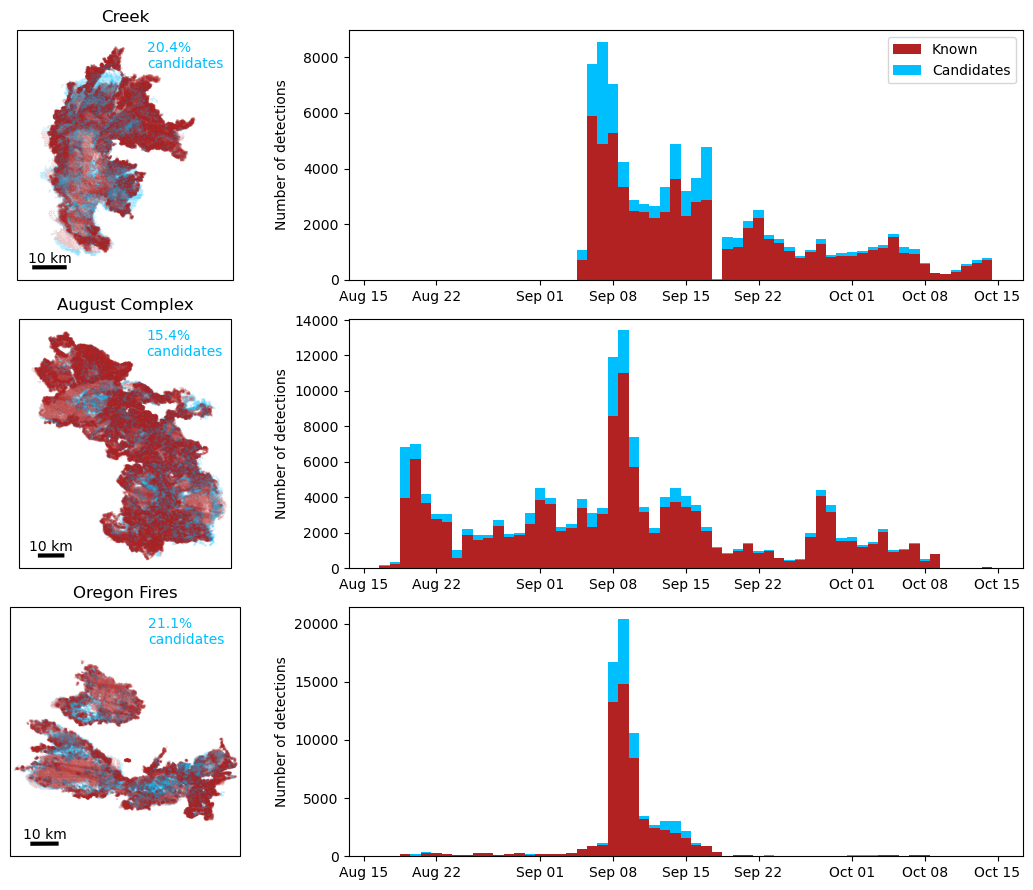

In [9]:
#figure 3 - creek, august complex, beachie creek map and timeseries plot
dets['color'] = 'firebrick'
dets.loc[dets.fire_mask < 7, 'color'] = 'deepskyblue'

fig = plt.figure(figsize=(11,9)) 
grid = gs.GridSpec(3,2, width_ratios=[1,2]) 

#creek
ax = plt.subplot(grid[0], projection = ccrs.Miller())
ax2 = plt.subplot(grid[1])
extent = [-119.6,-118.8,36.9,37.7]
map_and_timeseries(ax, ax2, dets, 'CREEK', extent)
ax2.legend()

#august complext
ax3 = plt.subplot(grid[2], projection = ccrs.Miller())
ax4 = plt.subplot(grid[3])
extent = [-123.6, -122.5, 39.4, 40.5]
map_and_timeseries(ax3, ax4, dets, 'AUGUST COMPLEX', extent)

#beachie creek
ax5 = plt.subplot(grid[4], projection = ccrs.Miller())
ax6 = plt.subplot(grid[5])
extent = [-122.7, -121.5, 44.45, 45.5]
map_and_timeseries(ax5, ax6, dets, 'OREGON FIRES', extent)

plt.tight_layout()
fig.align_ylabels()
#plt.savefig('/projects/my-public-bucket/figures/fig3_timeseries.png', dpi=350)
plt.savefig('/projects/my-public-bucket/figures/fig3_timeseries.pdf')

## Stats on candidate counts and frp contributions per fire

In [10]:
for fire in feds.index:
    
    data = dets[dets.fireid==fire]
    
    feds.loc[fire,'n_cand'] = (data.confidence=='x').sum()
    feds.loc[fire,'n_total'] = len(data)
    feds.loc[fire,'perc_cand'] = feds.loc[fire,'n_cand'] / feds.loc[fire,'n_total'] * 100
    #feds.loc[fire,'perc_frp'] = data.loc[data.confidence=='x', 'frp'].sum() / data.frp.sum() * 100 #percentage of total FRP in candidates
    feds.loc[fire,'perc_frp'] = (data.frp.sum() - data.frp_old.sum() )/ data.frp_old.sum() * 100 #percentage boost to FRP after adding cands

#add row for totals - 20 and 95 fires
feds = feds.sort_values('farea', ascending=False)

top20 = feds.index[:20]
subset = dets[dets.fireid.isin(top20)]
feds.loc['total20','farea'] = feds.loc[top20,'farea'].sum()
feds.loc['total20','name'] = 'TOTAL20'
feds.loc['total20','n_cand'] = (subset.confidence=='x').sum()
feds.loc['total20','n_total'] = len(subset)
feds.loc['total20','perc_cand'] = feds.loc['total20','n_cand'] / feds.loc['total20','n_total'] * 100
feds.loc['total20','perc_frp'] = (subset.frp.sum() - subset.frp_old.sum() )/ subset.frp_old.sum() * 100 #percentage boost to FRP after adding cands

feds.loc['total95','farea'] = feds.farea[:-1].sum().sum()
feds.loc['total95','name'] = 'TOTAL95'
feds.loc['total95','n_cand'] = (dets.confidence=='x').sum()
feds.loc['total95','n_total'] = len(dets)
feds.loc['total95','perc_cand'] = feds.loc['total95','n_cand'] / feds.loc['total95','n_total'] * 100
feds.loc['total95','perc_frp'] = (dets.frp.sum() - dets.frp_old.sum() )/ dets.frp_old.sum() * 100 #percentage boost to FRP after adding cands

In [11]:
feds

,fireid,farea,startdate,enddate,name,geometry,n_cand,n_total,perc_cand,perc_frp
fireid,,,,,,,,,,
F11445,F11445,4493.471804,2020-08-17 00:00:00,2020-11-25 00:00:00,AUGUST COMPLEX,"POLYGON ((-122.59844 39.56282, -122.59844 39.5...",23638.0,153628.0,15.386518,4.303685
F11440,F11440,1894.388484,2020-08-17 00:00:00,2020-10-29 12:00:00,LIONSHEAD,"MULTIPOLYGON (((-121.52187 44.78768, -121.5218...",12459.0,58459.0,21.312373,6.831164
F12649,F12649,1768.278704,2020-09-05 00:00:00,2020-11-26 00:00:00,CREEK,"POLYGON ((-119.48839 37.37486, -119.48839 37.3...",20330.0,99749.0,20.381157,11.588721
F11393,F11393,1526.054850,2020-08-16 12:00:00,2020-09-27 12:00:00,SCU LIGHTNING COMPLEX,"POLYGON ((-121.37461 37.38389, -121.37456 37.3...",7116.0,25978.0,27.392409,5.732224
F11527,F11527,1400.560920,2020-08-18 00:00:00,2020-10-29 12:00:00,NORTH COMPLEX,"POLYGON ((-120.85137 39.92894, -120.85124 39.9...",5676.0,38906.0,14.589009,4.683771
...,...,...,...,...,...,...,...,...,...,...
F8915,F8915,27.390576,2020-06-29 12:00:00,2020-07-24 00:00:00,NaN,"POLYGON ((-112.20849 39.45123, -112.20861 39.4...",73.0,300.0,24.333333,18.755044
F11811,F11811,26.990939,2020-08-20 12:00:00,2020-09-17 12:00:00,NaN,"MULTIPOLYGON (((-111.39337 33.40974, -111.3933...",139.0,331.0,41.993958,11.849889
F12741,F12741,25.553905,2020-09-06 12:00:00,2020-10-09 00:00:00,NaN,"POLYGON ((-111.78661 39.93267, -111.78660 39.9...",18.0,291.0,6.185567,0.346652


## Persistence calculation (fig 4) and tree cover

In [12]:
tree = rioxarray.open_rasterio('/projects/my-public-bucket/pct_tree-merged.tif')[0,:,:]
tree

<xarray.DataArray (y: 20252, x: 28179)> Size: 2GB
[570681108 values with dtype=float32]
Coordinates:
    band         int64 8B 1
  * x            (x) float64 225kB -126.9 -126.9 -126.9 ... -101.6 -101.6 -101.6
  * y            (y) float64 162kB 49.34 49.34 49.34 49.34 ... 31.15 31.15 31.15
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [13]:
clipped = tree.rio.clip(feds.geometry[:-2]) #skip "totals" rows

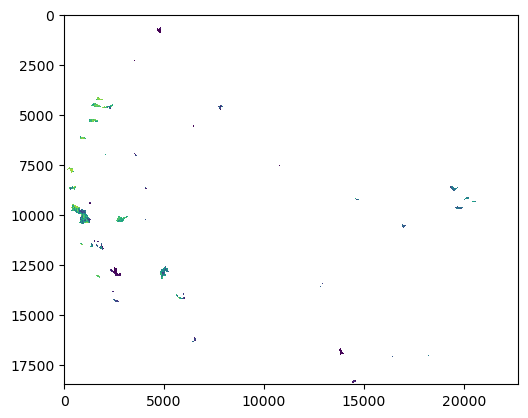

In [14]:
plt.imshow(clipped)

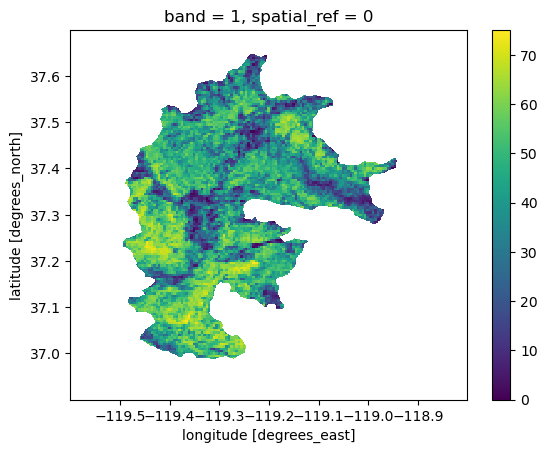

In [36]:
creek_tree = clipped.sel(x=slice(-119.6,-118.8), y=slice(37.7, 36.9))
creek_tree.plot()

20.78% more persistence including candidates


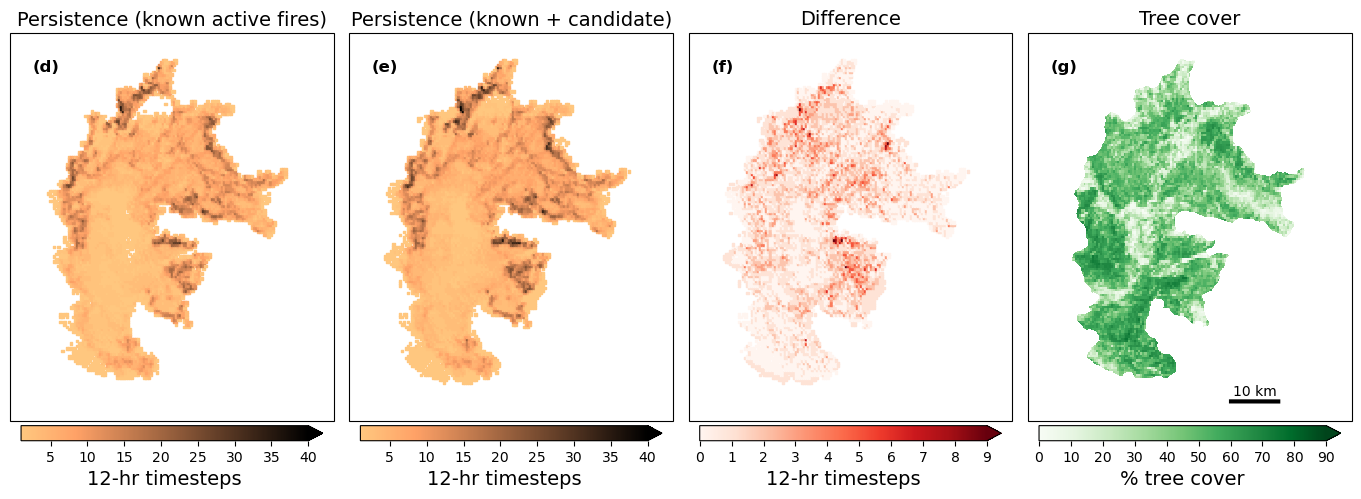

In [44]:
data = dets.copy()

data = data[data.name=='CREEK']
extent = [-119.6,-118.83,36.9,37.7]

#round to nearest 0.005 degree for a grid: multiply by 2, round to 2 decimals, divide by 2
data.longitude = (data.longitude*2).round(2) / 2
data.latitude = (data.latitude*2).round(2) / 2

#known dets only
subset = data[data.confidence!='x']
subset = subset[['longitude','latitude','acq_date','daynight']].drop_duplicates()
subset['counts'] = 1
subset = subset[['longitude','latitude','counts']].groupby(['longitude','latitude']).sum().reset_index()

#all dets
all_dets = data[['longitude','latitude','acq_date','daynight']].drop_duplicates()
all_dets['counts'] = 1
all_dets = all_dets[['longitude','latitude','counts']].groupby(['longitude','latitude']).sum().reset_index()

#fill in zeros
subset = subset.set_index(['longitude','latitude'])
all_dets = all_dets.set_index(['longitude','latitude'])
all_dets['counts_filled'] = 0
all_dets.loc[subset.index, 'counts_filled'] = subset.loc[subset.index, 'counts']
all_dets = all_dets.reset_index()
subset = subset.reset_index()

m1 = all_dets.counts_filled.mean()
m2 = all_dets.counts.mean()

fig = plt.figure(figsize=(18,6))
grid = gs.GridSpec(1,4)#, width_ratios=[1.2,1.2,1.2,1.2])

ax = plt.subplot(grid[0], projection = ccrs.Miller())
ax.set_extent(extent)
plot = ax.scatter(subset.longitude, subset.latitude, c=subset.counts, s=3, vmin=1, vmax=40, marker='s', transform=ccrs.Geodetic(), cmap='copper_r')
ax.set_title('Persistence (known active fires)', size=14)
ax.text(0.07, 0.9, '(d)', transform=ax.transAxes, fontweight='bold',fontsize='12')
cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.8, pad=0.01, ticks=np.arange(0,55,5), extend='max').set_label(label='12-hr timesteps',size=14)

ax2 = plt.subplot(grid[1], projection = ccrs.Miller())
ax2.set_extent(extent)
plot = ax2.scatter(all_dets.longitude, all_dets.latitude, c=all_dets.counts, s=3, vmin=1, vmax=40, marker='s', transform=ccrs.Geodetic(), cmap='copper_r')
ax2.set_title('Persistence (known + candidate)', size=14)
ax2.text(0.07, 0.9, '(e)', transform=ax2.transAxes, fontweight='bold',fontsize='12')
cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.8, pad=0.01, ticks=np.arange(0,55,5), extend='max').set_label(label='12-hr timesteps',size=14)

print('{:.2f}% more persistence including candidates'.format((m2-m1)/m1*100))

ax3 = plt.subplot(grid[2], projection = ccrs.Miller())
ax3.set_extent(extent)
plot = ax3.scatter(all_dets.longitude, all_dets.latitude, c=all_dets.counts - all_dets.counts_filled, s=3, vmin=0, vmax=9, marker='s', transform=ccrs.Geodetic(), cmap='Reds')
ax3.set_title('Difference', size=14)
ax3.text(0.07, 0.9, '(f)', transform=ax3.transAxes, fontweight='bold',fontsize='12')
cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.8, pad=0.01, ticks=np.arange(0,10), extend='max').set_label(label='12-hr timesteps',size=14)

#axis4 for tree cover
ax4 = plt.subplot(grid[3], projection = ccrs.Miller())
plot = ax4.pcolormesh(creek_tree.x, creek_tree.y, creek_tree, vmin=0, vmax=90, cmap='Greens', transform=ccrs.PlateCarree())
ax4.set_extent(extent)
ax4.set_title('Tree cover', size=14)
ax4.text(0.07, 0.9, '(g)', transform=ax4.transAxes, fontweight='bold',fontsize='12')
cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.8, pad=0.01, ticks=np.arange(0,91,10), extend='max').set_label(label='% tree cover',size=14)

scale_bar(ax4, 10)

for axs in [ax,ax2,ax3,ax4]:
    axs.set_anchor('N')

plt.subplots_adjust(wspace=-0.1)

#plt.tight_layout()
plt.savefig('/projects/my-public-bucket/figures/fig4_persistence.png', dpi=300)

#(not necessarily consecutive days)

In [37]:
#similar for other fires - calculate mean fire duration per pixel
warnings.filterwarnings('ignore')

for fire in feds.index[:-2]:
    
    data = dets[dets.fireid==fire]

    #round to nearest 0.005 degree for a grid: multiply by 2, round to 2 decimals, divide by 2
    data.longitude = (data.longitude*2).round(2) / 2
    data.latitude = (data.latitude*2).round(2) / 2

    all_dets = data[['longitude','latitude','acq_date','daynight']].drop_duplicates()
    all_dets['counts'] = 1

    all_dets = all_dets.groupby(['longitude','latitude']).counts.sum().reset_index()
    m2 = all_dets.counts.mean()
    
    feds.loc[fire,'mean_duration'] = m2

#again for "totals" rows ------
subset = dets[dets.fireid.isin(top20)]
subset.longitude = (subset.longitude*2).round(2) / 2
subset.latitude = (subset.latitude*2).round(2) / 2
subset = subset[['longitude','latitude','acq_date','daynight']].drop_duplicates()
subset['counts'] = 1
subset = subset.groupby(['longitude','latitude']).counts.sum().reset_index()

m2 = subset.counts.mean()
feds.loc['total20','mean_duration'] = m2

all_dets = dets.copy()
all_dets.longitude = (all_dets.longitude*2).round(2) / 2
all_dets.latitude = (all_dets.latitude*2).round(2) / 2
all_dets = all_dets[['longitude','latitude','acq_date','daynight']].drop_duplicates()
all_dets['counts'] = 1
all_dets = all_dets.groupby(['longitude','latitude']).counts.sum().reset_index()

m2 = all_dets.counts.mean()

feds.loc['total95','mean_duration'] = m2
feds

,fireid,farea,startdate,enddate,name,geometry,n_cand,n_total,perc_cand,perc_frp,mean_duration
fireid,,,,,,,,,,,
F11445,F11445,4493.471804,2020-08-17 00:00:00,2020-11-25 00:00:00,AUGUST COMPLEX,"POLYGON ((-122.59844 39.56282, -122.59844 39.5...",23638.0,153628.0,15.386518,4.303685,3.851801
F11440,F11440,1894.388484,2020-08-17 00:00:00,2020-10-29 12:00:00,LIONSHEAD,"MULTIPOLYGON (((-121.52187 44.78768, -121.5218...",12459.0,58459.0,21.312373,6.831164,3.095831
F12649,F12649,1768.278704,2020-09-05 00:00:00,2020-11-26 00:00:00,CREEK,"POLYGON ((-119.48839 37.37486, -119.48839 37.3...",20330.0,99749.0,20.381157,11.588721,6.149232
F11393,F11393,1526.054850,2020-08-16 12:00:00,2020-09-27 12:00:00,SCU LIGHTNING COMPLEX,"POLYGON ((-121.37461 37.38389, -121.37456 37.3...",7116.0,25978.0,27.392409,5.732224,1.893667
F11527,F11527,1400.560920,2020-08-18 00:00:00,2020-10-29 12:00:00,NORTH COMPLEX,"POLYGON ((-120.85137 39.92894, -120.85124 39.9...",5676.0,38906.0,14.589009,4.683771,3.133366
...,...,...,...,...,...,...,...,...,...,...,...
F8915,F8915,27.390576,2020-06-29 12:00:00,2020-07-24 00:00:00,NaN,"POLYGON ((-112.20849 39.45123, -112.20861 39.4...",73.0,300.0,24.333333,18.755044,1.403361
F11811,F11811,26.990939,2020-08-20 12:00:00,2020-09-17 12:00:00,NaN,"MULTIPOLYGON (((-111.39337 33.40974, -111.3933...",139.0,331.0,41.993958,11.849889,1.316770
F12741,F12741,25.553905,2020-09-06 12:00:00,2020-10-09 00:00:00,NaN,"POLYGON ((-111.78661 39.93267, -111.78660 39.9...",18.0,291.0,6.185567,0.346652,1.535354


In [38]:
#make pretty and export: Table 1
export = feds.copy()
export['name'] = export.name.str.title()
export = export[['name','farea','n_cand','n_total','perc_cand','perc_frp','mean_duration']]
export.to_csv('/projects/my-public-bucket/figures/Table1_events_stats.csv',index=False)
export

,name,farea,n_cand,n_total,perc_cand,perc_frp,mean_duration
fireid,,,,,,,
F11445,August Complex,4493.471804,23638.0,153628.0,15.386518,4.303685,3.851801
F11440,Lionshead,1894.388484,12459.0,58459.0,21.312373,6.831164,3.095831
F12649,Creek,1768.278704,20330.0,99749.0,20.381157,11.588721,6.149232
F11393,Scu Lightning Complex,1526.054850,7116.0,25978.0,27.392409,5.732224,1.893667
F11527,North Complex,1400.560920,5676.0,38906.0,14.589009,4.683771,3.133366
...,...,...,...,...,...,...,...
F8915,NaN,27.390576,73.0,300.0,24.333333,18.755044,1.403361
F11811,NaN,26.990939,139.0,331.0,41.993958,11.849889,1.316770
F12741,NaN,25.553905,18.0,291.0,6.185567,0.346652,1.535354


In [66]:
#day vs nighttime stats
day = dets[dets.daynight=='D']
night = dets[dets.daynight=='N']

print('daytime', (day.confidence=='x').sum() / len(day) * 100, '% candidates')
print('nighttime', (night.confidence=='x').sum() / len(night) * 100, '% candidates')

print('daytime', (day.confidence=='x').sum() / (day.confidence!='x').sum() * 100, '% boost')
print('nighttime',(night.confidence=='x').sum() / (night.confidence!='x').sum() * 100, '% boost')

daytime 30.823272171509693 % candidates
nighttime 10.95797634410689 % candidates
daytime 44.557285577209946 % boost
nighttime 12.306522127635462 % boost


In [68]:
#day vs nighttime stats - creek
subset = dets[dets.name=='CREEK']
day = subset[subset.daynight=='D']
night = subset[subset.daynight=='N']

print('creek fire only')
print('daytime', (day.confidence=='x').sum() / len(day) * 100, '% candidates')
print('nighttime', (night.confidence=='x').sum() / len(night) * 100, '% candidates')

print('daytime', (day.confidence=='x').sum() / (day.confidence!='x').sum() * 100, '% boost')
print('nighttime',(night.confidence=='x').sum() / (night.confidence!='x').sum() * 100, '% boost')

creek fire only
daytime 38.728679679760084 % candidates
nighttime 9.400339732700875 % candidates
daytime 63.208495389590524 % boost
nighttime 10.375689825951607 % boost


<h4>August Complex & Oregon fires persistence</h4>

15.00% more persistence including candidates


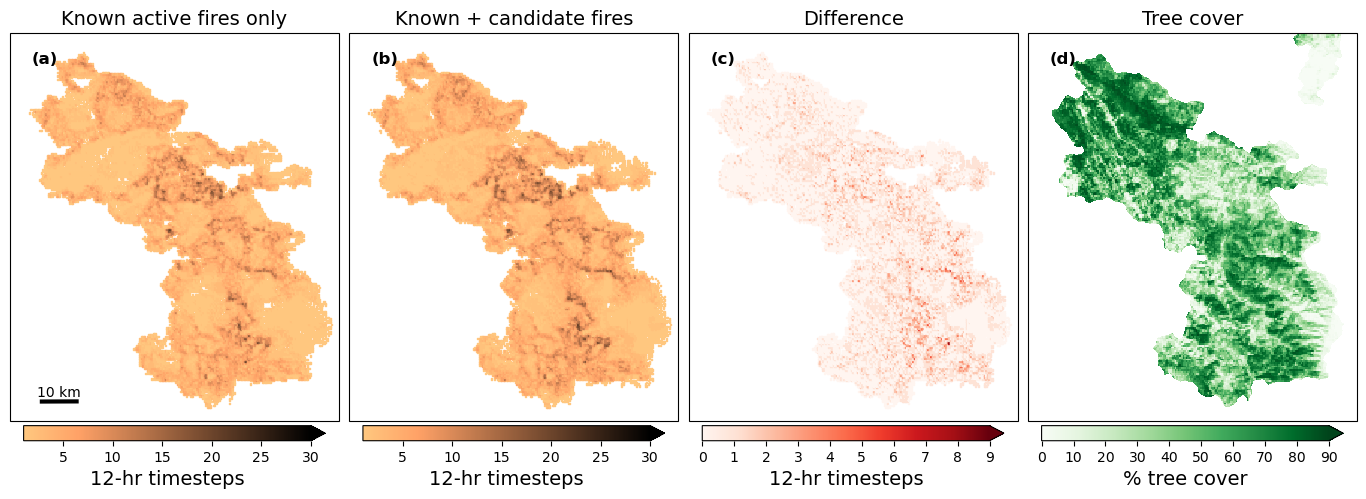

In [50]:
data = dets.copy()

data = data[data.name=='AUGUST COMPLEX']
extent = [-123.6, -122.5, 39.4, 40.5]

#round to nearest 0.005 degree for a grid: multiply by 2, round to 2 decimals, divide by 2
data.longitude = (data.longitude*2).round(2) / 2
data.latitude = (data.latitude*2).round(2) / 2

#known dets only
subset = data[data.confidence!='x']
subset = subset[['longitude','latitude','acq_date','daynight']].drop_duplicates()
subset['counts'] = 1
subset = subset[['longitude','latitude','counts']].groupby(['longitude','latitude']).sum().reset_index()

#all dets
all_dets = data[['longitude','latitude','acq_date','daynight']].drop_duplicates()
all_dets['counts'] = 1
all_dets = all_dets[['longitude','latitude','counts']].groupby(['longitude','latitude']).sum().reset_index()

#fill in zeros
subset = subset.set_index(['longitude','latitude'])
all_dets = all_dets.set_index(['longitude','latitude'])
all_dets['counts_filled'] = 0
all_dets.loc[subset.index, 'counts_filled'] = subset.loc[subset.index, 'counts']
all_dets = all_dets.reset_index()
subset = subset.reset_index()

m1 = all_dets.counts_filled.mean()
m2 = all_dets.counts.mean()

fig = plt.figure(figsize=(18,6))
grid = gs.GridSpec(1,4)#, width_ratios=[1.2,1.2,1.2,1.2])

ax = plt.subplot(grid[0], projection = ccrs.Miller())
ax.set_extent(extent)
plot = ax.scatter(subset.longitude, subset.latitude, c=subset.counts, s=1, vmin=1, vmax=30, marker='s', transform=ccrs.Geodetic(), cmap='copper_r')
ax.set_title('Known active fires only', size=14)
ax.text(0.067, 0.92, '(a)', transform=ax.transAxes, fontweight='bold',fontsize='12')
cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.8, pad=0.01, ticks=np.arange(0,55,5), extend='max').set_label(label='12-hr timesteps',size=14)

ax2 = plt.subplot(grid[1], projection = ccrs.Miller())
ax2.set_extent(extent)
plot = ax2.scatter(all_dets.longitude, all_dets.latitude, c=all_dets.counts, s=1, vmin=1, vmax=30, marker='s', transform=ccrs.Geodetic(), cmap='copper_r')
ax2.set_title('Known + candidate fires', size=14)
ax2.text(0.067, 0.92, '(b)', transform=ax2.transAxes, fontweight='bold',fontsize='12')
cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.8, pad=0.01, ticks=np.arange(0,55,5), extend='max').set_label(label='12-hr timesteps',size=14)

print('{:.2f}% more persistence including candidates'.format((m2-m1)/m1*100))

ax3 = plt.subplot(grid[2], projection = ccrs.Miller())
ax3.set_extent(extent)
plot = ax3.scatter(all_dets.longitude, all_dets.latitude, c=all_dets.counts - all_dets.counts_filled, s=1, vmin=0, vmax=9, marker='s', transform=ccrs.Geodetic(), cmap='Reds')
ax3.set_title('Difference', size=14)
ax3.text(0.067, 0.92, '(c)', transform=ax3.transAxes, fontweight='bold',fontsize='12')
cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.8, pad=0.01, ticks=np.arange(0,10), extend='max').set_label(label='12-hr timesteps',size=14)

#axis4 for tree cover
august_tree = clipped.sel(x=slice(extent[0],extent[1]), y=slice(extent[3], extent[2]))
ax4 = plt.subplot(grid[3], projection = ccrs.Miller())
plot = ax4.pcolormesh(august_tree.x, august_tree.y, august_tree, vmin=0, vmax=90, cmap='Greens', transform=ccrs.PlateCarree())
ax4.set_extent(extent)
ax4.set_title('Tree cover', size=14)
ax4.text(0.067, 0.92, '(d)', transform=ax4.transAxes, fontweight='bold',fontsize='12')
cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.8, pad=0.01, ticks=np.arange(0,91,10), extend='max').set_label(label='% tree cover',size=14)

scale_bar(ax, 10)

for axs in [ax,ax2,ax3,ax4]:
    axs.set_anchor('N')

plt.subplots_adjust(wspace=-0.1)

#plt.tight_layout()

21.64% more persistence including candidates


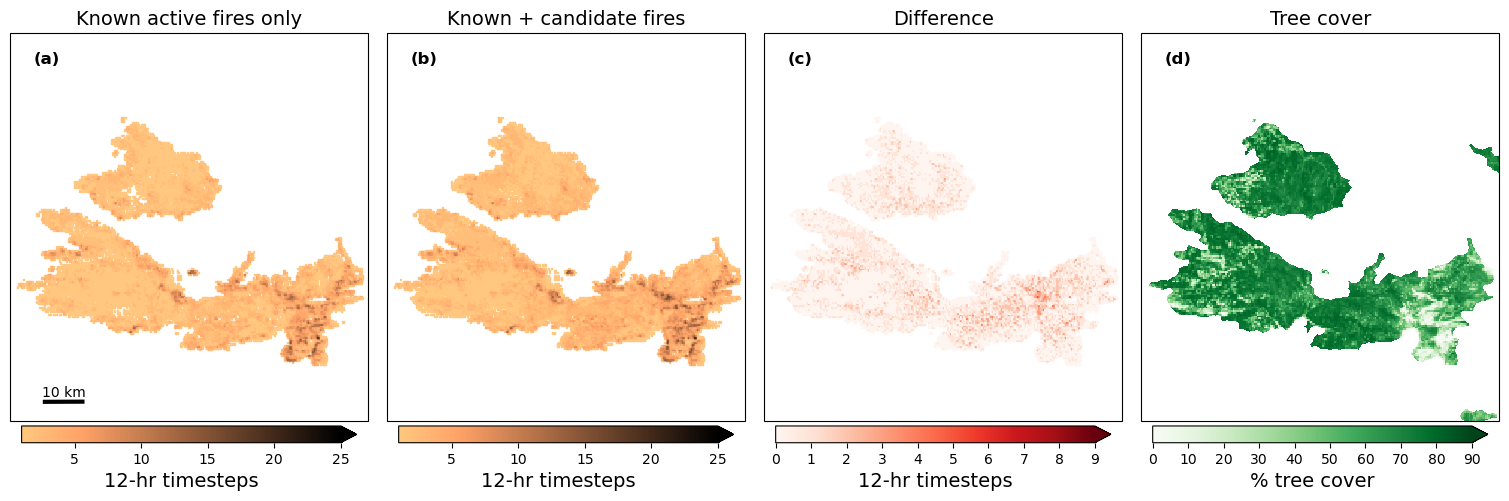

In [54]:
data = dets.copy()

data = data[data.name.isin(['RIVERSIDE','LIONSHEAD'])]
extent = [-122.7, -121.5, 44.45, 45.5]

#round to nearest 0.005 degree for a grid: multiply by 2, round to 2 decimals, divide by 2
data.longitude = (data.longitude*2).round(2) / 2
data.latitude = (data.latitude*2).round(2) / 2

#known dets only
subset = data[data.confidence!='x']
subset = subset[['longitude','latitude','acq_date','daynight']].drop_duplicates()
subset['counts'] = 1
subset = subset[['longitude','latitude','counts']].groupby(['longitude','latitude']).sum().reset_index()

#all dets
all_dets = data[['longitude','latitude','acq_date','daynight']].drop_duplicates()
all_dets['counts'] = 1
all_dets = all_dets[['longitude','latitude','counts']].groupby(['longitude','latitude']).sum().reset_index()

#fill in zeros
subset = subset.set_index(['longitude','latitude'])
all_dets = all_dets.set_index(['longitude','latitude'])
all_dets['counts_filled'] = 0
all_dets.loc[subset.index, 'counts_filled'] = subset.loc[subset.index, 'counts']
all_dets = all_dets.reset_index()
subset = subset.reset_index()

m1 = all_dets.counts_filled.mean()
m2 = all_dets.counts.mean()

fig = plt.figure(figsize=(20,6))
grid = gs.GridSpec(1,4)#, width_ratios=[1.2,1.2,1.2,1.2])

ax = plt.subplot(grid[0], projection = ccrs.Miller())
ax.set_extent(extent)
plot = ax.scatter(subset.longitude, subset.latitude, c=subset.counts, s=1, vmin=1, vmax=25, marker='s', transform=ccrs.Geodetic(), cmap='copper_r')
ax.set_title('Known active fires only', size=14)
ax.text(0.067, 0.92, '(a)', transform=ax.transAxes, fontweight='bold',fontsize='12')
cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.8, pad=0.01, ticks=np.arange(0,55,5), extend='max').set_label(label='12-hr timesteps',size=14)

ax2 = plt.subplot(grid[1], projection = ccrs.Miller())
ax2.set_extent(extent)
plot = ax2.scatter(all_dets.longitude, all_dets.latitude, c=all_dets.counts, s=1, vmin=1, vmax=25, marker='s', transform=ccrs.Geodetic(), cmap='copper_r')
ax2.set_title('Known + candidate fires', size=14)
ax2.text(0.067, 0.92, '(b)', transform=ax2.transAxes, fontweight='bold',fontsize='12')
cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.8, pad=0.01, ticks=np.arange(0,55,5), extend='max').set_label(label='12-hr timesteps',size=14)

print('{:.2f}% more persistence including candidates'.format((m2-m1)/m1*100))

ax3 = plt.subplot(grid[2], projection = ccrs.Miller())
ax3.set_extent(extent)
plot = ax3.scatter(all_dets.longitude, all_dets.latitude, c=all_dets.counts - all_dets.counts_filled, s=1, vmin=0, vmax=9, marker='s', transform=ccrs.Geodetic(), cmap='Reds')
ax3.set_title('Difference', size=14)
ax3.text(0.067, 0.92, '(c)', transform=ax3.transAxes, fontweight='bold',fontsize='12')
cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.8, pad=0.01, ticks=np.arange(0,10), extend='max').set_label(label='12-hr timesteps',size=14)

#axis4 for tree cover
oregon_tree = clipped.sel(x=slice(extent[0],extent[1]), y=slice(extent[3], extent[2]))
ax4 = plt.subplot(grid[3], projection = ccrs.Miller())
plot = ax4.pcolormesh(oregon_tree.x, oregon_tree.y, oregon_tree, vmin=0, vmax=90, cmap='Greens', transform=ccrs.PlateCarree())
ax4.set_extent(extent)
ax4.set_title('Tree cover', size=14)
ax4.text(0.067, 0.92, '(d)', transform=ax4.transAxes, fontweight='bold',fontsize='12')
cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.8, pad=0.01, ticks=np.arange(0,91,10), extend='max').set_label(label='% tree cover',size=14)

scale_bar(ax, 10)

for axs in [ax,ax2,ax3,ax4]:
    axs.set_anchor('N')

plt.subplots_adjust(wspace=-0.1)

#plt.tight_layout()

<h4>Full western US set's persistence

20.13% more persistence including candidates


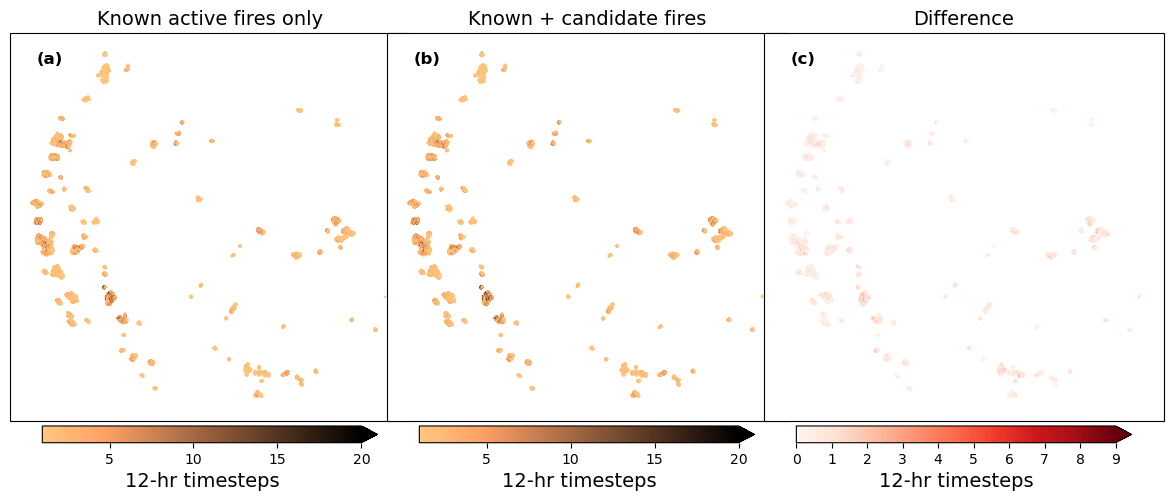

In [85]:
extent = [-125,-102,31,49.2] #western us

data = dets.copy()

#round to nearest 0.005 degree for a grid: multiply by 2, round to 2 decimals, divide by 2
data.longitude = (data.longitude*2).round(2) / 2
data.latitude = (data.latitude*2).round(2) / 2

#known dets only
subset = data[data.confidence!='x']
subset = subset[['longitude','latitude','acq_date','daynight']].drop_duplicates()
subset['counts'] = 1
subset = subset[['longitude','latitude','counts']].groupby(['longitude','latitude']).sum().reset_index()

#all dets
all_dets = data[['longitude','latitude','acq_date','daynight']].drop_duplicates()
all_dets['counts'] = 1
all_dets = all_dets[['longitude','latitude','counts']].groupby(['longitude','latitude']).sum().reset_index()

#fill in zeros
subset = subset.set_index(['longitude','latitude'])
all_dets = all_dets.set_index(['longitude','latitude'])
all_dets['counts_filled'] = 0
all_dets.loc[subset.index, 'counts_filled'] = subset.loc[subset.index, 'counts']
all_dets = all_dets.reset_index()
subset = subset.reset_index()

m1 = all_dets.counts_filled.mean()
m2 = all_dets.counts.mean()

fig = plt.figure(figsize=(20,6))
grid = gs.GridSpec(1,4)#, width_ratios=[1.2,1.2,1.2,1.2])

ax = plt.subplot(grid[0], projection = ccrs.Miller())
ax.set_extent(extent)
plot = ax.scatter(subset.longitude, subset.latitude, c=subset.counts, s=0.1, vmin=1, vmax=20, marker='s', transform=ccrs.Geodetic(), cmap='copper_r')
ax.set_title('Known active fires only', size=14)
ax.text(0.067, 0.92, '(a)', transform=ax.transAxes, fontweight='bold',fontsize='12')
cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.8, pad=0.01, ticks=np.arange(0,55,5), extend='max').set_label(label='12-hr timesteps',size=14)

ax2 = plt.subplot(grid[1], projection = ccrs.Miller())
ax2.set_extent(extent)
plot = ax2.scatter(all_dets.longitude, all_dets.latitude, c=all_dets.counts, s=0.1, vmin=1, vmax=20, marker='s', transform=ccrs.Geodetic(), cmap='copper_r')
ax2.set_title('Known + candidate fires', size=14)
ax2.text(0.067, 0.92, '(b)', transform=ax2.transAxes, fontweight='bold',fontsize='12')
cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.8, pad=0.01, ticks=np.arange(0,55,5), extend='max').set_label(label='12-hr timesteps',size=14)

print('{:.2f}% more persistence including candidates'.format((m2-m1)/m1*100))

ax3 = plt.subplot(grid[2], projection = ccrs.Miller())
ax3.set_extent(extent)
plot = ax3.scatter(all_dets.longitude, all_dets.latitude, c=all_dets.counts - all_dets.counts_filled, s=0.1, vmin=0, vmax=9, marker='s', transform=ccrs.Geodetic(), cmap='Reds')
ax3.set_title('Difference', size=14)
ax3.text(0.067, 0.92, '(c)', transform=ax3.transAxes, fontweight='bold',fontsize='12')
cbar = plt.colorbar(plot, orientation='horizontal', shrink=0.8, pad=0.01, ticks=np.arange(0,10), extend='max').set_label(label='12-hr timesteps',size=14)


for axs in [ax,ax2,ax3,ax4]:
    axs.set_anchor('N')

plt.subplots_adjust(wspace=-0.1)

In [86]:
print('new persistence, old persistence', m2, m1)

new persistence, old persistence 2.9726454121637444 2.4744442157996693


<h2>Tree cover

In [15]:
clipped

<xarray.DataArray (y: 18488, x: 22718)> Size: 2GB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
    band         int64 8B 1
  * x            (x) float64 182kB -123.8 -123.8 -123.8 ... -103.4 -103.4 -103.4
  * y            (y) float64 148kB 48.93 48.93 48.93 48.93 ... 32.32 32.32 32.32
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

In [16]:
#extract tree cover for each point (#breaks kernel to plot full clipped raster)
x = dets.longitude.to_xarray()
y = dets.latitude.to_xarray()
dets['tree_cover'] = tree.sel(x=x, y=y, method='nearest').data
dets = dets.sample(frac=0.2)

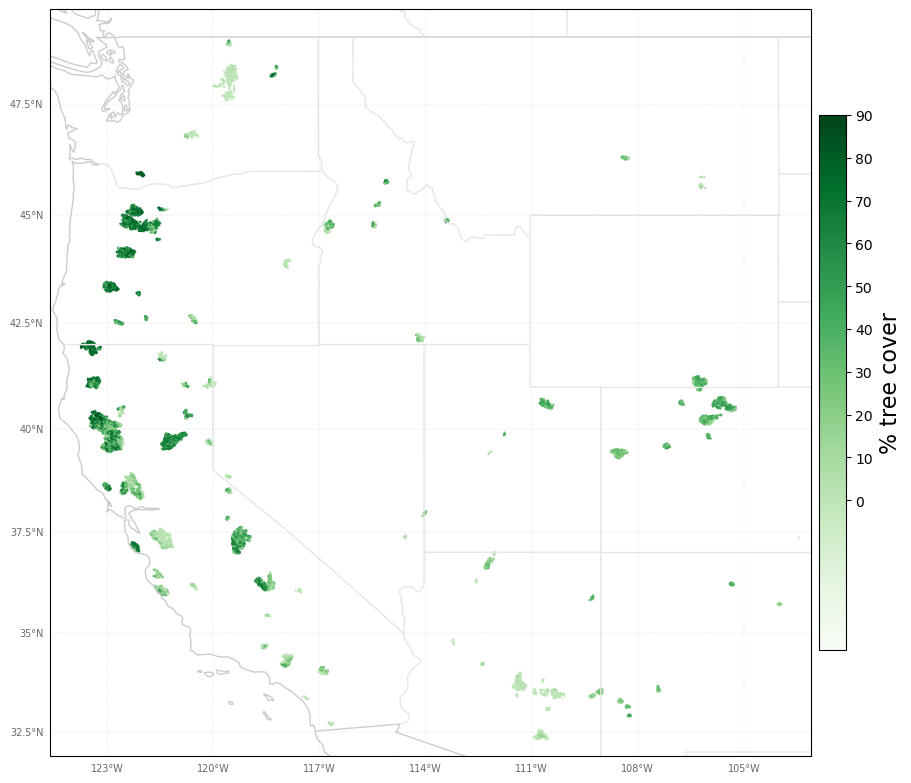

In [19]:
fig, ax = plt.subplots(1,1, subplot_kw={'projection': cartopy.crs.Miller()}, constrained_layout=True, figsize=(9,9))
ax.set_extent([-124.6,-103.1,31.9,49.1]) #Western US

states_provinces = cartopy.feature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='50m',
    facecolor='none')
ax.add_feature(cartopy.feature.BORDERS, edgecolor='0.8')
ax.add_feature(cartopy.feature.COASTLINE, edgecolor='0.8')
ax.add_feature(states_provinces, edgecolor='0.9')

#plot = ax.pcolormesh(creek_tree.x, creek_tree.y, creek_tree, vmin=0, vmax=90, cmap='Greens', transform=ccrs.PlateCarree())
plot = ax.scatter(dets.longitude, dets.latitude, c=dets.tree_cover, vmin=-35, vmax=90, s=0.01, marker='s', cmap='Greens', transform=ccrs.Geodetic())
#plot = ax.scatter(all_dets.longitude, all_dets.latitude, c=all_dets.tree_cover, s=0.01, vmin=-25, vmax=100, marker='s', transform=ccrs.Geodetic(), cmap='Greens')
cbar = plt.colorbar(plot, orientation='vertical', shrink=0.6, pad=0.01, ticks=np.arange(0,91,10)).set_label(label='% tree cover',size=16)

#gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.2, color='0.8', linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlines = True
gl.ylines = True
gl.xlabel_style = {'size': 7, 'color': 'dimgray'}
gl.ylabel_style = {'size': 7, 'color': 'dimgray'}